**Model 5 — BERTweet for GBV Tweet Classification**

This notebook investigates BERTweet, a transformer-based language model pretrained on English Twitter data, for classifying tweets into five gender-based violence categories. The model is evaluated using the same canonical train/validation/test split as Models 1–4. Because the dataset is highly imbalanced, macro-F1 is used as the primary evaluation metric.

In [ ]:
!pip install -q -U transformers datasets accelerate scikit-learn emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 37.1 MB/s eta 0:00:00


In [ ]:
#Imports

import os
import re
import json
import random
import time
import copy
import hashlib
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
#Set random seeds

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [ ]:
#Define the five lables

LABELS = [
    "sexual_violence",
    "physical_violence",
    "emotional_violence",
    "economic_violence",
    "harmful_traditional_practice"
]

LABEL2ID = {
    label: i
    for i, label in enumerate(LABELS)
}

ID2LABEL = {
    i: label
    for label, i in LABEL2ID.items()
}

print(LABEL2ID)

{'sexual_violence': 0, 'physical_violence': 1, 'emotional_violence': 2, 'economic_violence': 3, 'harmful_traditional_practice': 4}


In [ ]:
#Mount google drive

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
BASE = Path("/content/drive/MyDrive/gbv_tweet_project")
SPLIT_DIR = BASE / "data" / "splits"

print("Split directory:", SPLIT_DIR)
print(list(SPLIT_DIR.iterdir()))

Split directory: /content/drive/MyDrive/gbv_tweet_project/data/splits
[PosixPath('/content/drive/MyDrive/gbv_tweet_project/data/splits/train.csv'), PosixPath('/content/drive/MyDrive/gbv_tweet_project/data/splits/split_manifest.json'), PosixPath('/content/drive/MyDrive/gbv_tweet_project/data/splits/val.csv'), PosixPath('/content/drive/MyDrive/gbv_tweet_project/data/splits/test.csv'), PosixPath('/content/drive/MyDrive/gbv_tweet_project/data/splits/low_resource_protocol.json')]


In [ ]:
#Load person 1's data

train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df = pd.read_csv(SPLIT_DIR / "val.csv")
test_df = pd.read_csv(SPLIT_DIR / "test.csv")

with open(SPLIT_DIR / "low_resource_protocol.json", "r") as f:
    protocol = json.load(f)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nLow-resource sizes:")
print(protocol["sizes"])

print("\nSeeds:")
print(protocol["seeds"])

Train: (27764, 4)
Validation: (5941, 4)
Test: (5945, 4)

Columns:
['Tweet_ID', 'tweet', 'text', 'label']

Low-resource sizes:
[250, 500, 1000, 2500, 'full']

Seeds:
[42, 1337, 2024]


In [ ]:
#Verfiy labels

for df in [train_df, val_df, test_df]:
    df["label"] = df["label"].astype(str).str.strip().str.lower()
    df["label_id"] = df["label"].map(LABEL2ID)

print(train_df["label"].value_counts())

label
sexual_violence                 22856
physical_violence                4169
emotional_violence                456
economic_violence                 152
harmful_traditional_practice      131
Name: count, dtype: int64


In [ ]:
assert train_df["label_id"].notna().all()
assert val_df["label_id"].notna().all()
assert test_df["label_id"].notna().all()

print("All labels successfully mapped.")

All labels successfully mapped.


In [ ]:
#Verify the same splits

def md5sum(path):
    h = hashlib.md5()

    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1 << 20), b""):
            h.update(block)

    return h.hexdigest()

In [ ]:
# Verify that the canonical train/validation/test splits
# are exactly the same as the group's shared splits.

EXPECTED_MD5 = {
    "train.csv": "7eb4634bdd6ee53babecffcbe2013354",
    "val.csv": "849d1a4e1d7789f8be43933071b02374",
    "test.csv": "1af88d754c02f35ca339ba992444ed56"
}

for filename, expected_hash in EXPECTED_MD5.items():

    path = SPLIT_DIR / filename
    actual_hash = md5sum(path)

    print(
        f"{filename}: {actual_hash}"
    )

    assert actual_hash == expected_hash, (
        f"MD5 mismatch for {filename}!\n"
        f"Expected: {expected_hash}\n"
        f"Found:    {actual_hash}"
    )

print("All canonical split MD5 checks passed.")

train.csv: 7eb4634bdd6ee53babecffcbe2013354
val.csv: 849d1a4e1d7789f8be43933071b02374
test.csv: 1af88d754c02f35ca339ba992444ed56
All canonical split MD5 checks passed.


In [ ]:
# Check the inherited data

print("Train class distribution:")
print(train_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_df["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())

Train class distribution:
label
sexual_violence                 22856
physical_violence                4169
emotional_violence                456
economic_violence                 152
harmful_traditional_practice      131
Name: count, dtype: int64

Validation class distribution:
label
sexual_violence                 4895
physical_violence                888
emotional_violence                98
economic_violence                 32
harmful_traditional_practice      28
Name: count, dtype: int64

Test class distribution:
label
sexual_violence                 4897
physical_violence                889
emotional_violence                97
economic_violence                 33
harmful_traditional_practice      29
Name: count, dtype: int64


In [ ]:
print("\nExample tweets:")
display(train_df[["tweet", "text", "label"]].head(10))


Example tweets:


,tweet,text,label
0,Had a dream i got raped last night. By a guy i...,Had a dream i got raped last night. By a guy i...,sexual_violence
1,he thought the word raped means sex and told m...,he thought the word raped means sex and told m...,sexual_violence
2,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,I was sexually abused for 3 years at age 4 to ...,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,"Yes men rape women. But women also rape men, y...","Yes men rape women. But women also rape men, y...",sexual_violence
5,"My Husband Beats Me Frequently, Wife Tells Cou...","My Husband Beats Me Frequently, Wife Tells Cou...",physical_violence
6,Pretty sure he raped a 16yr old girl with 2 fr...,Pretty sure he raped a 16yr old girl with 2 fr...,sexual_violence
7,TW sorry to hear that and yeah he recently th...,TW sorry to hear that and yeah he recently thr...,sexual_violence
8,"""I understand that... My father was abusive as...","""I understand that... My father was abusive as...",sexual_violence
9,"BABY! Soon, all the notes in case ya'll suck y...","BABY! Soon, all the notes in case ya'll suck y...",sexual_violence


## 1. Model Selection: Why BERTweet?

BERTweet was selected as Model 5 because the task involves classifying short, informal Twitter messages, making a Twitter-pretrained language model particularly relevant to the problem.

Unlike the TF-IDF + Logistic Regression and TF-IDF + Linear SVM approaches, BERTweet does not rely only on manually constructed word or character frequency representations. It uses contextual representations learned through transformer self-attention, allowing the model to consider relationships between tokens within a tweet.

BERTweet is also substantially different from the TextCNN and BiLSTM models used in Models 3 and 4. TextCNN focuses on local patterns through convolutional filters, while BiLSTM processes sequential information through recurrent units. BERTweet instead uses transformer-based attention to model contextual relationships across the input sequence.

The model is therefore included to investigate whether a pretrained transformer that was specifically developed for Twitter language can provide useful improvements for this GBV classification problem, particularly where tweets contain informal or context-dependent language.

BERTweet is based on RoBERTa and was pretrained on a large collection of English Tweets, making it a suitable pretrained representation for this Twitter-based task.

In [ ]:
#Define model 5

MODEL_NAME = "vinai/bertweet-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    normalization=True,
    use_fast=False
)

print("Tokenizer loaded with BERTweet normalization.")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

Tokenizer loaded with BERTweet normalization.


In [ ]:
#Examine tokenisation

sample_texts = train_df["text"].sample(
    1000,
    random_state=SEED
).tolist()

token_lengths = []

for text in sample_texts:
    tokens = tokenizer(
        str(text),
        truncation=False,
        add_special_tokens=True
    )

    token_lengths.append(len(tokens["input_ids"]))

token_lengths = np.array(token_lengths)

print("Median:", np.median(token_lengths))
print("90th percentile:", np.percentile(token_lengths, 90))
print("95th percentile:", np.percentile(token_lengths, 95))
print("99th percentile:", np.percentile(token_lengths, 99))
print("Maximum:", token_lengths.max())

Median: 52.5
90th percentile: 68.0
95th percentile: 71.0
99th percentile: 77.0
Maximum: 87


In [ ]:
#Choose maximum sequence length

MAX_LENGTH = 80

print("BERTweet maximum sequence length:", MAX_LENGTH)

BERTweet maximum sequence length: 80


## 2. Input Representation and Maximum Sequence Length

BERTweet uses subword tokenisation rather than the whitespace-based word representation used by the earlier TF-IDF models. This allows the model to represent words and smaller word pieces, which is useful for informal social-media text where spelling variation, abbreviations, hashtags, mentions, and uncommon expressions may occur.

A sample of 1,000 training tweets was tokenised without truncation to examine the distribution of BERTweet sequence lengths. The median, 90th, 95th, and 99th percentiles, together with the maximum sequence length, are reported above.

A maximum sequence length of 80 tokens is used for the experiments. This provides enough capacity for most tweets while limiting unnecessary padding and computational cost. Tweets longer than this limit are truncated, while shorter tweets are padded to the same length so that they can be processed efficiently in batches.

The choice of 80 is therefore a practical trade-off between retaining tweet information and controlling the computational cost of transformer fine-tuning.

In [ ]:
#Create dataset class

class GBVDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length):

        self.texts = dataframe["text"].astype(str).tolist()
        self.labels = dataframe["label_id"].tolist()

        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )

        item = {
            key: value.squeeze(0)
            for key, value in encoding.items()
        }

        item["labels"] = torch.tensor(
            label,
            dtype=torch.long
        )

        return item

In [ ]:
#Create dataset

train_dataset = GBVDataset(
    train_df,
    tokenizer,
    MAX_LENGTH
)

val_dataset = GBVDataset(
    val_df,
    tokenizer,
    MAX_LENGTH
)

test_dataset = GBVDataset(
    test_df,
    tokenizer,
    MAX_LENGTH
)

print("Train examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))

Train examples: 27764
Validation examples: 5941
Test examples: 5945


In [ ]:
#Inspect one encoded tweet

example = train_dataset[0]

print(example.keys())

print("\nInput IDs shape:")
print(example["input_ids"].shape)

print("\nAttention mask shape:")
print(example["attention_mask"].shape)

print("\nLabel:")
print(example["labels"])

dict_keys(['input_ids', 'attention_mask', 'labels'])

Input IDs shape:
torch.Size([80])

Attention mask shape:
torch.Size([80])

Label:
tensor(0)


In [ ]:
#Create DataLoaders

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders ready.")

DataLoaders ready.


## 3. Handling Class Imbalance

The dataset contains substantial class imbalance, with some GBV categories occurring much more frequently than others. In a highly imbalanced classification problem, a model can obtain relatively high overall accuracy while performing poorly on minority classes.

To reduce this problem, class-weighted cross-entropy loss is used during BERTweet training. The weights give relatively greater importance to less frequent classes, encouraging the model to learn from minority examples rather than primarily optimising for the majority class.

The weights are calculated from the training-set class frequencies using an inverse square-root transformation. This provides additional emphasis to minority classes while avoiding extremely large weights that could make optimisation unstable.

The validation and test sets are not used to calculate the class weights, ensuring that information from the evaluation data does not influence training.

In [ ]:
#Calculate class weights

class_counts = (
    train_df["label_id"]
    .value_counts()
    .reindex(range(len(LABELS)))
    .fillna(0)
)

print(class_counts)

label_id
0    22856
1     4169
2      456
3      152
4      131
Name: count, dtype: int64


In [ ]:
weights = 1.0 / np.sqrt(
    class_counts.values + 1
)

weights = (
    weights / weights.sum()
) * len(LABELS)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32,
    device=DEVICE
)

print("Class weights:")
for label, weight in zip(LABELS, class_weights):
    print(f"{label:35s} {weight.item():.4f}")

Class weights:
sexual_violence                     0.1397
physical_violence                   0.3270
emotional_violence                  0.9879
economic_violence                   1.7073
harmful_traditional_practice        1.8381


In [ ]:
#Build BERTweet classifiers

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

model.to(DEVICE)

print("Model loaded.")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.


In [ ]:
#Optimizer

LEARNING_RATE = 2e-5
EPOCHS = 5

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Optimizer ready.")

Optimizer ready.


## 4. Evaluation Metric

Macro-F1 is used as the primary evaluation metric because the GBV dataset is highly imbalanced.

Macro-F1 calculates the F1 score independently for each class and then gives each class equal importance when averaging the scores. This prevents the large majority class from dominating the overall evaluation and makes the metric more informative for assessing performance across all five GBV categories.

Accuracy is also reported because it provides an intuitive measure of overall classification correctness. However, accuracy alone can be misleading under severe class imbalance. Balanced accuracy is included because it gives equal importance to the recall of each class, while weighted F1 is included to show performance when each class is weighted according to its frequency.

Therefore, macro-F1 is used for model selection and comparison, while the other metrics provide additional context about the model's behaviour.

In [ ]:
#Evaluation function

def evaluate_model(model, loader):

    model.eval()

    all_predictions = []
    all_labels = []

    total_loss = 0

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            loss = criterion(
                logits,
                labels
            )

            total_loss += loss.item()

            predictions = torch.argmax(
                logits,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    balanced_acc = balanced_accuracy_score(
        all_labels,
        all_predictions
    )

    weighted_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "loss": total_loss / len(loader),
        "macro_f1": macro_f1,
        "accuracy": accuracy,
        "balanced_acc": balanced_acc,
        "weighted_f1": weighted_f1,
        "predictions": np.array(all_predictions),
        "labels": np.array(all_labels)
    }

## 5. Training Strategy and Early Stopping

BERTweet is fine-tuned using the AdamW optimiser with a linear learning-rate schedule and a short warm-up period. Gradient clipping is also applied to reduce the risk of unstable parameter updates.

Early stopping is used because continuing to train a neural model after validation performance stops improving can lead to overfitting. After each epoch, the model is evaluated on the validation set and the validation macro-F1 is recorded.

The model checkpoint with the highest validation macro-F1 is retained. If validation macro-F1 fails to improve for two consecutive epochs, training is stopped early.

This means that the specified maximum number of epochs is not necessarily the number of epochs actually used by the final model. The validation results determine which training point is retained.

In [ ]:
#Training loop

def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    epochs=5,
    patience=2
):

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_f1": [],
        "val_accuracy": []
    }

    best_f1 = -1
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):

        model.train()

        total_train_loss = 0

        for batch in train_loader:

            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            loss = criterion(
                logits,
                labels
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()

        train_loss = (
            total_train_loss /
            len(train_loader)
        )

        val_results = evaluate_model(
            model,
            val_loader
        )

        val_loss = val_results["loss"]
        val_f1 = val_results["macro_f1"]
        val_acc = val_results["accuracy"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_f1)
        history["val_accuracy"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val macro-F1: {val_f1:.4f} | "
            f"Val accuracy: {val_acc:.4f}"
        )

        if val_f1 > best_f1:

            best_f1 = val_f1

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1

            if patience_counter >= patience:

                print("Early stopping.")

                break

    model.load_state_dict(best_state)

    return model, history

In [ ]:
#Evaluate on validation

val_results = evaluate_model(
    model,
    val_loader
)

print("Validation results")

print(
    f"Macro-F1:       {val_results['macro_f1']:.4f}"
)

print(
    f"Accuracy:       {val_results['accuracy']:.4f}"
)

print(
    f"Balanced Acc:   {val_results['balanced_acc']:.4f}"
)

print(
    f"Weighted F1:    {val_results['weighted_f1']:.4f}"
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

Validation results
Macro-F1:       0.0072
Accuracy:       0.0081
Balanced Acc:   0.2047
Weighted F1:    0.0051


In [ ]:
#Creating a function for experiments

def build_bertweet():

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        id2label=ID2LABEL,
        label2id=LABEL2ID
    )

    model.to(DEVICE)

    return model

In [ ]:
#Function to run an experiment

def run_bertweet_experiment(
    learning_rate,
    epochs=4,
    batch_size=16
):

    print("=" * 70)

    print(
        f"Learning rate: {learning_rate}"
    )

    print(
        f"Batch size: {batch_size}"
    )

    print("=" * 70)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = build_bertweet()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate
    )

    total_steps = len(train_loader) * epochs

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    model, history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        scheduler,
        criterion,
        epochs=epochs,
        patience=2
    )

    results = evaluate_model(
        model,
        val_loader
    )

    return model, history, results

## 6. Hyperparameter Tuning: Learning Rate

The learning rate controls the size of the parameter updates made during fine-tuning. A learning rate that is too large can cause unstable updates or move the pretrained model away from useful representations too quickly, while a rate that is too small can result in slow learning.

Three learning rates are therefore investigated:

- 1e-5
- 2e-5
- 3e-5

These values represent a small range of learning rates appropriate for fine-tuning a pretrained transformer. Each configuration is evaluated on the same validation set, and validation macro-F1 is used to select the best configuration.

The test set is not used during this tuning stage so that it remains an independent evaluation of the selected model.

In [ ]:
#Run three configurations

TUNING_RESULTS = []

learning_rates = [
    1e-5,
    2e-5,
    3e-5
]

for lr in learning_rates:

    model_temp, history_temp, results_temp = run_bertweet_experiment(
        learning_rate=lr,
        epochs=4,
        batch_size=16
    )

    TUNING_RESULTS.append({
        "learning_rate": lr,
        "macro_f1": results_temp["macro_f1"],
        "accuracy": results_temp["accuracy"],
        "balanced_acc": results_temp["balanced_acc"],
        "weighted_f1": results_temp["weighted_f1"]
    })

Learning rate: 1e-05
Batch size: 16


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4 | Train loss: 0.3062 | Val loss: 0.0154 | Val macro-F1: 0.9950 | Val accuracy: 0.9993
Epoch 2/4 | Train loss: 0.0103 | Val loss: 0.0188 | Val macro-F1: 0.9941 | Val accuracy: 0.9993
Epoch 3/4 | Train loss: 0.0051 | Val loss: 0.0223 | Val macro-F1: 0.9940 | Val accuracy: 0.9992
Early stopping.
Learning rate: 2e-05
Batch size: 16


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4 | Train loss: 0.2267 | Val loss: 0.0214 | Val macro-F1: 0.9823 | Val accuracy: 0.9988
Epoch 2/4 | Train loss: 0.0118 | Val loss: 0.0211 | Val macro-F1: 0.9828 | Val accuracy: 0.9987
Epoch 3/4 | Train loss: 0.0035 | Val loss: 0.0232 | Val macro-F1: 0.9941 | Val accuracy: 0.9993
Epoch 4/4 | Train loss: 0.0006 | Val loss: 0.0221 | Val macro-F1: 0.9931 | Val accuracy: 0.9992
Learning rate: 3e-05
Batch size: 16


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4 | Train loss: 0.1902 | Val loss: 0.0357 | Val macro-F1: 0.9829 | Val accuracy: 0.9983
Epoch 2/4 | Train loss: 0.0108 | Val loss: 0.0419 | Val macro-F1: 0.9834 | Val accuracy: 0.9985
Epoch 3/4 | Train loss: 0.0067 | Val loss: 0.0183 | Val macro-F1: 0.9940 | Val accuracy: 0.9992
Epoch 4/4 | Train loss: 0.0015 | Val loss: 0.0156 | Val macro-F1: 0.9930 | Val accuracy: 0.9990


In [ ]:
#Display tuning results

tuning_df = pd.DataFrame(
    TUNING_RESULTS
)

display(
    tuning_df.sort_values(
        "macro_f1",
        ascending=False
    )
)

,learning_rate,macro_f1,accuracy,balanced_acc,weighted_f1
0,0.00001,0.995041,0.999327,0.992550,0.999326
1,0.00002,0.994128,0.999327,0.990550,0.999325
2,0.00003,0.994016,0.999158,0.992509,0.999159


In [ ]:
BEST_LR = tuning_df.loc[
    tuning_df["macro_f1"].idxmax(),
    "learning_rate"
]

print("Best learning rate:", BEST_LR)

Best learning rate: 1e-05


## 7. Validation-Based Model Selection and Final Test Evaluation

The validation set is used for model development decisions, including learning-rate selection and early stopping. This allows different configurations to be compared without using the final evaluation data.

After the best learning rate is identified using validation macro-F1, the selected configuration is used to train the final BERTweet model. The test set is then used to provide the final performance estimate.

Keeping the test set separate from model selection is important because repeatedly using test performance to make training or hyperparameter decisions would make the test results less independent and could lead to an overly optimistic estimate of generalisation performance.

In [ ]:
#Training my final BERTweet model

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

final_model = build_bertweet()

optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=BEST_LR
)

EPOCHS = 5

total_steps = (
    len(train_loader) *
    EPOCHS
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(
        0.1 * total_steps
    ),
    num_training_steps=total_steps
)

final_model, final_history = train_model(
    final_model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    epochs=EPOCHS,
    patience=2
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5 | Train loss: 0.3255 | Val loss: 0.0225 | Val macro-F1: 0.9864 | Val accuracy: 0.9990
Epoch 2/5 | Train loss: 0.0062 | Val loss: 0.0187 | Val macro-F1: 0.9907 | Val accuracy: 0.9993
Epoch 3/5 | Train loss: 0.0022 | Val loss: 0.0223 | Val macro-F1: 0.9906 | Val accuracy: 0.9992
Epoch 4/5 | Train loss: 0.0013 | Val loss: 0.0218 | Val macro-F1: 0.9905 | Val accuracy: 0.9990
Early stopping.


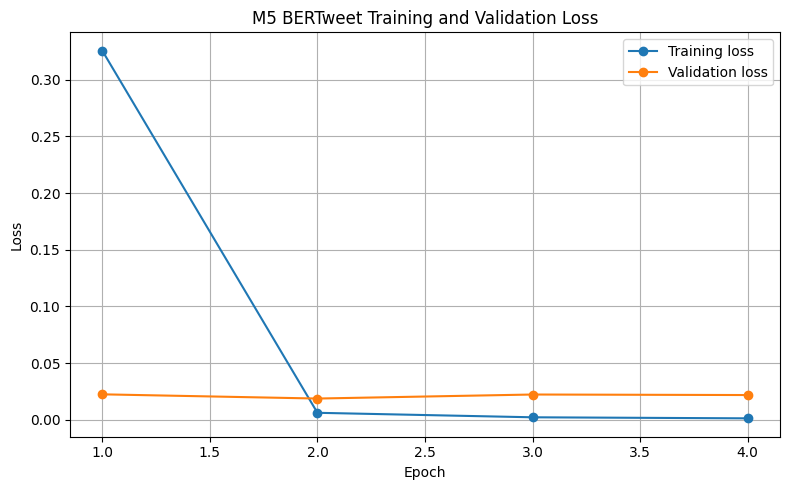

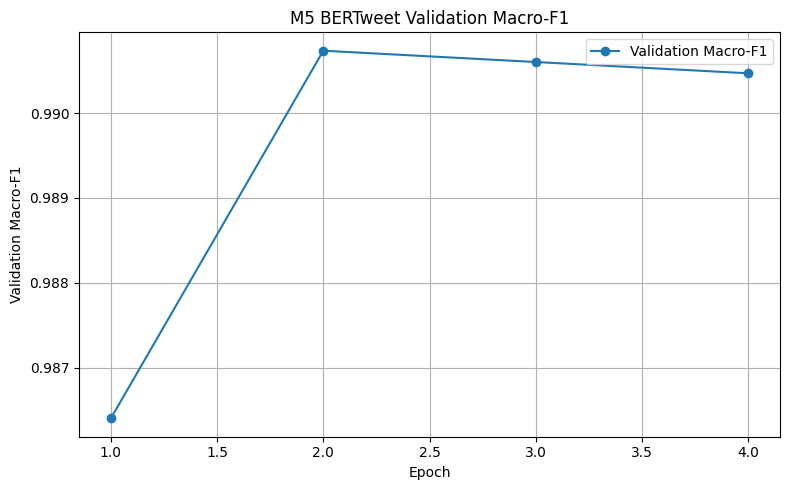

Saved final M5 learning curves.


In [ ]:
# Save final M5 BERTweet learning curves

FINAL_FIG_DIR = BASE / "figures"
FINAL_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

epochs = range(
    1,
    len(final_history["train_loss"]) + 1
)

# Training vs validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    final_history["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    final_history["val_loss"],
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("M5 BERTweet Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    FINAL_FIG_DIR / "08_m5_bertweet_learning_curve_loss.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# Validation Macro-F1


plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    final_history["val_macro_f1"],
    marker="o",
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Macro-F1")
plt.title("M5 BERTweet Validation Macro-F1")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    FINAL_FIG_DIR / "09_m5_bertweet_validation_macro_f1.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved final M5 learning curves.")

##  Final Evaluation on the Test Set

After hyperparameter selection and validation-based early stopping, the selected BERTweet configuration is evaluated on the held-out test set.

The test set is used only at this stage to estimate how well the final model generalises to previously unseen tweets. Macro-F1 is the primary metric, with accuracy, balanced accuracy, and weighted F1 reported as supporting metrics.

Per-class precision, recall, and F1 are also examined because overall metrics may hide differences in performance between the five GBV categories.

In [ ]:
#Touching the test set

test_results = evaluate_model(
    final_model,
    test_loader
)

In [ ]:
print("=" * 60)
print("FINAL MODEL 5 — BERTWEET TEST RESULTS")
print("=" * 60)

print(
    f"Macro-F1:       {test_results['macro_f1']:.4f}"
)

print(
    f"Accuracy:       {test_results['accuracy']:.4f}"
)

print(
    f"Balanced Acc:   {test_results['balanced_acc']:.4f}"
)

print(
    f"Weighted F1:    {test_results['weighted_f1']:.4f}"
)

FINAL MODEL 5 — BERTWEET TEST RESULTS
Macro-F1:       0.9988
Accuracy:       0.9997
Balanced Acc:   0.9999
Weighted F1:    0.9997


In [ ]:
#Pre-class results

y_true = test_results["labels"]
y_pred = test_results["predictions"]

print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(len(LABELS))),
        target_names=LABELS,
        digits=4,
        zero_division=0
    )
)

                              precision    recall  f1-score   support

             sexual_violence     1.0000    0.9996    0.9998      4897
           physical_violence     0.9989    1.0000    0.9994       889
          emotional_violence     0.9898    1.0000    0.9949        97
           economic_violence     1.0000    1.0000    1.0000        33
harmful_traditional_practice     1.0000    1.0000    1.0000        29

                    accuracy                         0.9997      5945
                   macro avg     0.9977    0.9999    0.9988      5945
                weighted avg     0.9997    0.9997    0.9997      5945



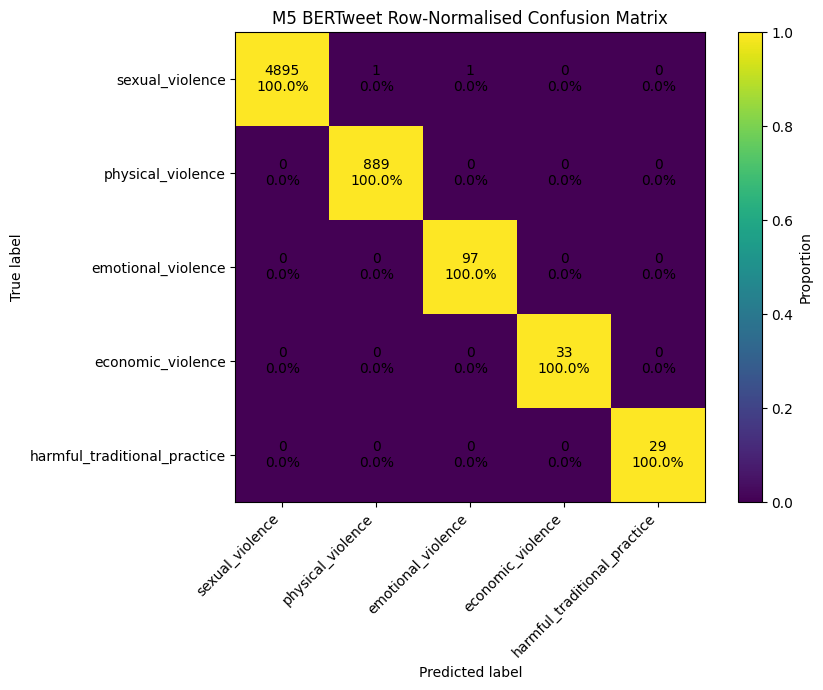

Confusion matrix saved to:
/content/drive/MyDrive/gbv_tweet_project/figures/10_m5_bertweet_confusion_matrix.png


In [ ]:
# -----------------------------------------
# Row-normalised confusion matrix
# -----------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(LABELS)))
)

# Convert each row to proportions
# so that each actual class sums to 1.
cm_normalized = (
    cm.astype(float)
    / cm.sum(axis=1, keepdims=True)
)

FIG_DIR = BASE / "figures"
FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

im = ax.imshow(
    cm_normalized,
    interpolation="nearest"
)

fig.colorbar(
    im,
    ax=ax,
    label="Proportion"
)

ax.set_xticks(
    range(len(LABELS))
)

ax.set_xticklabels(
    LABELS,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(len(LABELS))
)

ax.set_yticklabels(
    LABELS
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_title(
    "M5 BERTweet Row-Normalised Confusion Matrix"
)

# Add both count and percentage to each cell
for i in range(len(LABELS)):
    for j in range(len(LABELS)):

        ax.text(
            j,
            i,
            f"{cm[i, j]}\n"
            f"{cm_normalized[i, j]:.1%}",
            ha="center",
            va="center"
        )

fig.tight_layout()

# SAVE BEFORE SHOW
confusion_path = (
    FIG_DIR /
    "10_m5_bertweet_confusion_matrix.png"
)

fig.savefig(
    confusion_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

print(
    f"Confusion matrix saved to:\n{confusion_path}"
)

In [ ]:
FIG_DIR = BASE / "figures"
FIG_DIR.mkdir(exist_ok=True)

plt.savefig(
    FIG_DIR / "07_cm_m5_bertweet.png",
    dpi=200,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
#Save my test predictions

error_df = test_df[
    ["Tweet_ID", "tweet", "text", "label"]
].copy()

error_df["predicted_label"] = [
    ID2LABEL[p]
    for p in y_pred
]

error_df["correct"] = (
    error_df["label"] ==
    error_df["predicted_label"]
)

error_df.to_csv(
    BASE / "results" /
    "test_predictions_m5_bertweet.csv",
    index=False
)

print("Saved BERTweet predictions.")

Saved BERTweet predictions.


##  Error Analysis

Overall performance metrics do not explain which types of tweets are difficult for BERTweet to classify. Error analysis is therefore conducted on the held-out test predictions.

The analysis examines incorrectly classified tweets, class-specific error rates, and differences in tweet length between correctly and incorrectly classified examples. These analyses help identify whether particular GBV categories are more difficult to distinguish and whether tweet length is associated with classification errors.

The confusion matrix and per-class precision, recall, and F1 scores are also used to identify systematic confusion between categories. These observations provide evidence for the limitations of the model and help motivate possible future improvements.

In [ ]:
#Finding the errors

errors = error_df[
    error_df["correct"] == False
].copy()

print(
    f"Total errors: {len(errors)} / {len(error_df)}"
)

display(
    errors[
        [
            "Tweet_ID",
            "tweet",
            "label",
            "predicted_label"
        ]
    ].head(30)
)

Total errors: 2 / 5945


,Tweet_ID,tweet,label,predicted_label
412,ID_2HHGOH7E,In 2006 a on members of the team. This accused...,sexual_violence,emotional_violence
5303,ID_W1TWJIMD,i wnna be raped by my Daddy while he beats me ...,sexual_violence,physical_violence


In [ ]:
#Finding the hardest minority classes

error_df["correct"] = error_df["correct"].astype(int)

class_error = (
    error_df
    .groupby("label")["correct"]
    .agg(
        total="count",
        correct="sum"
    )
)

class_error["error_rate"] = (
    1 -
    class_error["correct"] /
    class_error["total"]
)

display(
    class_error.sort_values(
        "error_rate",
        ascending=False
    )
)

,total,correct,error_rate
label,,,
sexual_violence,4897,4895,0.000408
economic_violence,33,33,0.000000
emotional_violence,97,97,0.000000
harmful_traditional_practice,29,29,0.000000
physical_violence,889,889,0.000000


In [ ]:
#Compare correct vs incorrect tweet lengths

error_df["n_words"] = (
    error_df["text"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    error_df
    .groupby("correct")["n_words"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
0,2.0,24.500000,13.435029,15.0,19.75,24.5,29.25,34.0
1,5943.0,39.016827,15.069883,3.0,27.00,44.0,52.00,68.0


## 8. Low-Resource Experiment

The assignment also requires investigation of how the selected sequential approaches behave under limited training data. This experiment therefore evaluates BERTweet using smaller subsets of the training data while keeping the validation and test sets unchanged.

The predefined low-resource protocol contains training subsets of different sizes. For the initial BERTweet investigation, subsets of 250, 500, and 1,000 training tweets are evaluated using the same validation and test sets.

The purpose of this experiment is not simply to obtain the highest score, but to investigate sample efficiency: how much performance can BERTweet achieve when only a limited number of labelled tweets are available?

Training and validation loss and validation macro-F1 are recorded for each low-resource run. These learning curves are used to determine whether the chosen maximum number of epochs is sufficient or whether validation performance is still improving when training ends.

In [ ]:
#Load the exact low-resource subsets

SIZES = protocol["sizes"]
SEEDS = protocol["seeds"]

print(SIZES)
print(SEEDS)

[250, 500, 1000, 2500, 'full']
[42, 1337, 2024]


In [ ]:
def get_subset(size, seed):

    if size == "full":
        return train_df.copy()

    ids = set(
        protocol["subsets"][
            f"n{size}_seed{seed}"
        ]
    )

    return train_df[
        train_df["Tweet_ID"].isin(ids)
    ].reset_index(drop=True)

In [ ]:
def make_class_weighted_criterion(dataframe):

    subset_counts = (
        dataframe["label_id"]
        .value_counts()
        .reindex(range(len(LABELS)))
        .fillna(0)
    )

    subset_weights = (
        1.0 /
        np.sqrt(subset_counts.values + 1)
    )

    subset_weights = (
        subset_weights /
        subset_weights.sum()
    ) * len(LABELS)

    subset_class_weights = torch.tensor(
        subset_weights,
        dtype=torch.float32,
        device=DEVICE
    )

    return nn.CrossEntropyLoss(
        weight=subset_class_weights
    )

In [ ]:
import numpy as np

# Run low-resource BERTweet experiments
# and save the complete learning histories

sample_results = []
low_resource_histories = {}

LOW_RESOURCE_SIZES = [250, 500, 1000]

for size in LOW_RESOURCE_SIZES:

    seed = 42

    subset = get_subset(size, seed)

    print("\n" + "=" * 70)
    print(f"Training size: {size}")
    print("=" * 70)

    # Create dataset for this training subset
    subset_dataset = GBVDataset(
        subset,
        tokenizer,
        MAX_LENGTH
    )

    # Create training DataLoader
    subset_loader = DataLoader(
        subset_dataset,
        batch_size=16,
        shuffle=True
    )

    # Build a fresh BERTweet model
    model_small = build_bertweet()

    # Optimizer uses the best learning rate selected earlier
    optimizer_small = torch.optim.AdamW(
        model_small.parameters(),
        lr=BEST_LR
    )

    # Allow up to 8 epochs.
    # Early stopping will stop training if validation
    # macro-F1 stops improving.
    epochs_small = 8

    total_steps_small = (
        len(subset_loader) * epochs_small
    )

    scheduler_small = get_linear_schedule_with_warmup(
        optimizer_small,
        num_warmup_steps=int(0.1 * total_steps_small),
        num_training_steps=total_steps_small
    )

    # Train and keep the complete learning history
    criterion_small = make_class_weighted_criterion(
    subset
)

    model_small, history_small = train_model(
        model_small,
        subset_loader,
        val_loader,
        optimizer_small,
        scheduler_small,
        criterion_small,
        epochs=epochs_small,
        patience=2
    )

    # Save the learning history so that it can be plotted later
    low_resource_histories[size] = history_small

    # Evaluate the selected checkpoint
    # on the test set for the final low-resource result
    test_small = evaluate_model(
        model_small,
        test_loader
    )

    # Calculate per-class F1 on the low-resource test result

    precision_small, recall_small, f1_small, support_small = (
        precision_recall_fscore_support(
            test_small["labels"],
            test_small["predictions"],
            labels=list(range(len(LABELS))),
            zero_division=0
        )
    )

    sample_results.append({
        "model": "M5 BERTweet",
        "train_size": size,
        "seed": seed,

        "epochs_trained": len(
            history_small["val_macro_f1"]
        ),

        "best_epoch": (
            np.argmax(
                history_small["val_macro_f1"]
            ) + 1
        ),

        "best_val_macro_f1": max(
            history_small["val_macro_f1"]
        ),

        "macro_f1": test_small["macro_f1"],
        "accuracy": test_small["accuracy"],
        "balanced_acc": test_small["balanced_acc"],
        "weighted_f1": test_small["weighted_f1"],

        "f1_sexual": f1_small[0],
        "f1_physical": f1_small[1],
        "f1_emotional": f1_small[2],
        "f1_economic": f1_small[3],
        "f1_harmful_traditional_practice": f1_small[4]
    })

    print(
        f"Training size: {size} | "
        f"Epochs trained: {len(history_small['val_macro_f1'])} | "
        f"Best validation Macro-F1: "
        f"{max(history_small['val_macro_f1']):.4f} | "
        f"Test Macro-F1: "
        f"{test_small['macro_f1']:.4f}"
    )



Training size: 250


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/8 | Train loss: 1.5213 | Val loss: 1.3214 | Val macro-F1: 0.1807 | Val accuracy: 0.8239
Epoch 2/8 | Train loss: 1.1858 | Val loss: 1.1050 | Val macro-F1: 0.1807 | Val accuracy: 0.8239
Epoch 3/8 | Train loss: 1.0562 | Val loss: 1.0046 | Val macro-F1: 0.1807 | Val accuracy: 0.8239
Early stopping.
Training size: 250 | Epochs trained: 3 | Best validation Macro-F1: 0.1807 | Test Macro-F1: 0.1807

Training size: 500


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/8 | Train loss: 1.4866 | Val loss: 1.1958 | Val macro-F1: 0.1807 | Val accuracy: 0.8239
Epoch 2/8 | Train loss: 1.0926 | Val loss: 0.9327 | Val macro-F1: 0.1916 | Val accuracy: 0.8280
Epoch 3/8 | Train loss: 0.7916 | Val loss: 0.6796 | Val macro-F1: 0.3888 | Val accuracy: 0.9647
Epoch 4/8 | Train loss: 0.6002 | Val loss: 0.5461 | Val macro-F1: 0.3877 | Val accuracy: 0.9673
Epoch 5/8 | Train loss: 0.4541 | Val loss: 0.5017 | Val macro-F1: 0.3896 | Val accuracy: 0.9687
Epoch 6/8 | Train loss: 0.4013 | Val loss: 0.4620 | Val macro-F1: 0.3884 | Val accuracy: 0.9684
Epoch 7/8 | Train loss: 0.3702 | Val loss: 0.4381 | Val macro-F1: 0.3883 | Val accuracy: 0.9684
Early stopping.
Training size: 500 | Epochs trained: 7 | Best validation Macro-F1: 0.3896 | Test Macro-F1: 0.3902

Training size: 1000


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/8 | Train loss: 1.3560 | Val loss: 0.9740 | Val macro-F1: 0.1807 | Val accuracy: 0.8239
Epoch 2/8 | Train loss: 0.8052 | Val loss: 0.5859 | Val macro-F1: 0.3923 | Val accuracy: 0.9692
Epoch 3/8 | Train loss: 0.5281 | Val loss: 0.4374 | Val macro-F1: 0.3890 | Val accuracy: 0.9709
Epoch 4/8 | Train loss: 0.3635 | Val loss: 0.3129 | Val macro-F1: 0.3965 | Val accuracy: 0.9717
Epoch 5/8 | Train loss: 0.2417 | Val loss: 0.2824 | Val macro-F1: 0.7391 | Val accuracy: 0.9849
Epoch 6/8 | Train loss: 0.1779 | Val loss: 0.2487 | Val macro-F1: 0.8204 | Val accuracy: 0.9882
Epoch 7/8 | Train loss: 0.1535 | Val loss: 0.2261 | Val macro-F1: 0.8401 | Val accuracy: 0.9891
Epoch 8/8 | Train loss: 0.1300 | Val loss: 0.2199 | Val macro-F1: 0.8532 | Val accuracy: 0.9896
Training size: 1000 | Epochs trained: 8 | Best validation Macro-F1: 0.8532 | Test Macro-F1: 0.8154


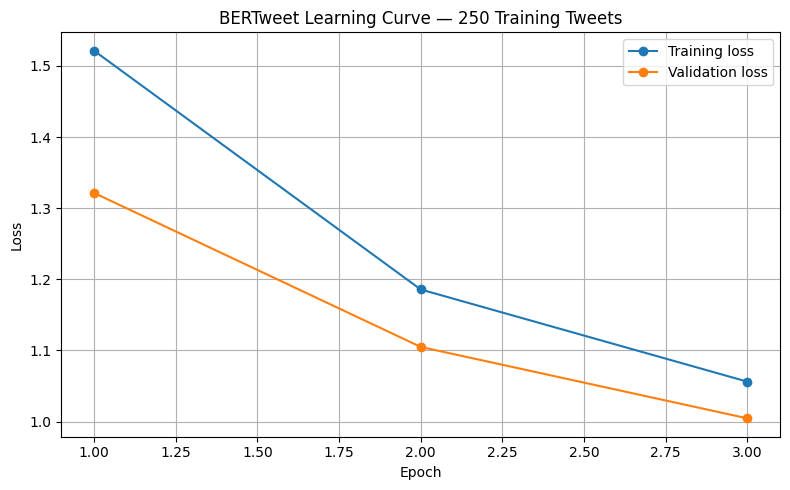

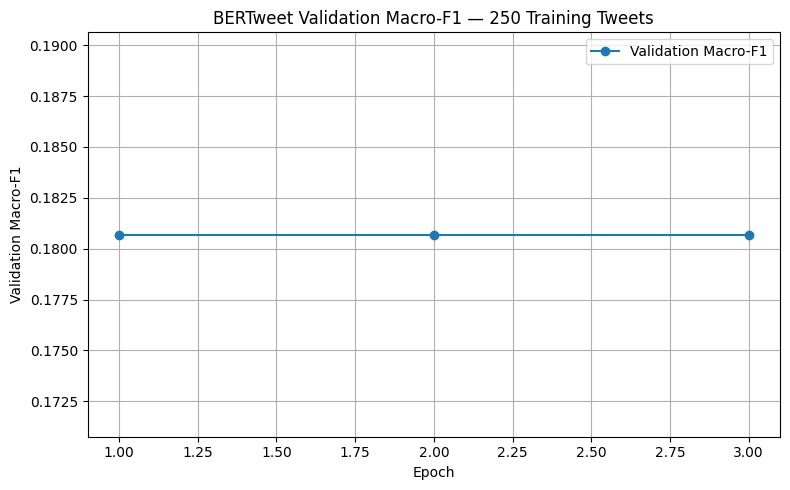

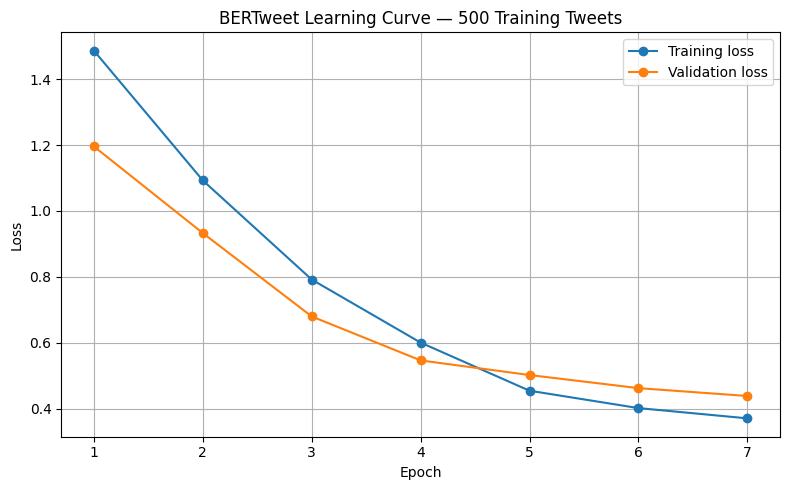

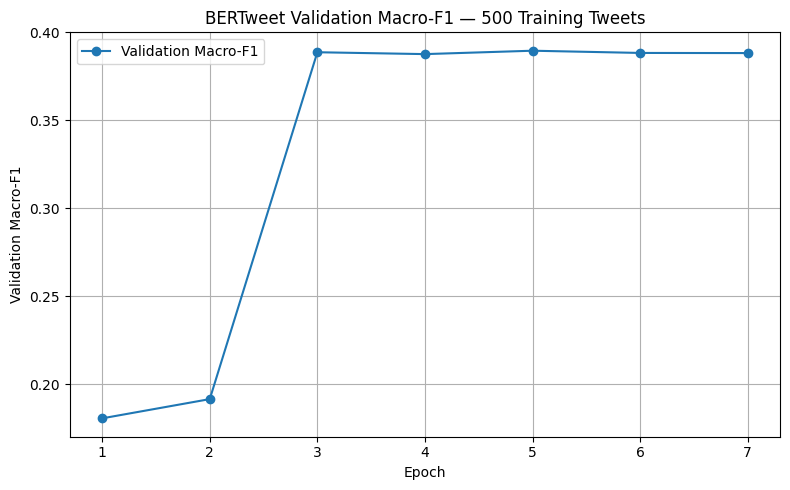

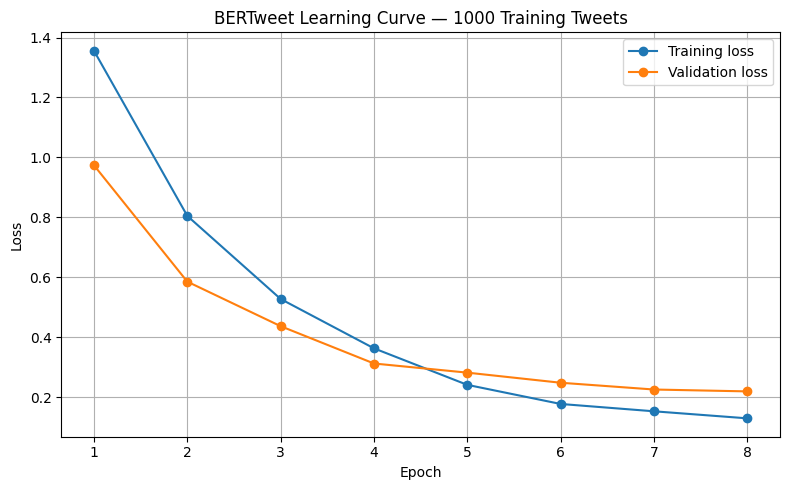

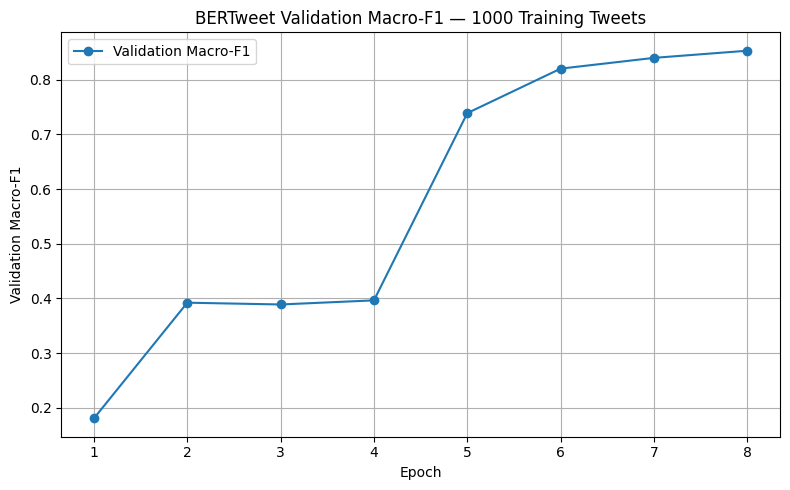

In [ ]:
# Plot learning curves for each low-resource training size

for size, history_small in low_resource_histories.items():

    epochs = range(1, len(history_small["train_loss"]) + 1)

    # Training and validation loss

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_small["train_loss"],
        marker="o",
        label="Training loss"
    )

    plt.plot(
        epochs,
        history_small["val_loss"],
        marker="o",
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        f"BERTweet Learning Curve — "
        f"{size} Training Tweets"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()



    # Validation Macro-F1

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_small["val_macro_f1"],
        marker="o",
        label="Validation Macro-F1"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Macro-F1")
    plt.title(
        f"BERTweet Validation Macro-F1 — "
        f"{size} Training Tweets"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

In [ ]:
#Put the low-resource results into a table

sample_results_df = pd.DataFrame(
    sample_results
)

display(sample_results_df)

,model,train_size,seed,epochs_trained,best_epoch,best_val_macro_f1,macro_f1,accuracy,balanced_acc,weighted_f1,f1_sexual,f1_physical,f1_emotional,f1_economic,f1_harmful_traditional_practice
0,M5 BERTweet,250,42,3,1,0.180694,0.180668,0.823717,0.200000,0.744096,0.903339,0.000000,0.000000,0.000000,0.000000
1,M5 BERTweet,500,42,7,5,0.389620,0.390193,0.969050,0.396401,0.955931,0.985180,0.965784,0.000000,0.000000,0.000000
2,M5 BERTweet,1000,42,8,8,0.853212,0.815434,0.987048,0.775825,0.985522,0.992686,0.989807,0.782123,0.969697,0.342857


In [ ]:
sample_results_df.to_csv(
    BASE / "results" /
    "results_model5_low_resource.csv",
    index=False
)

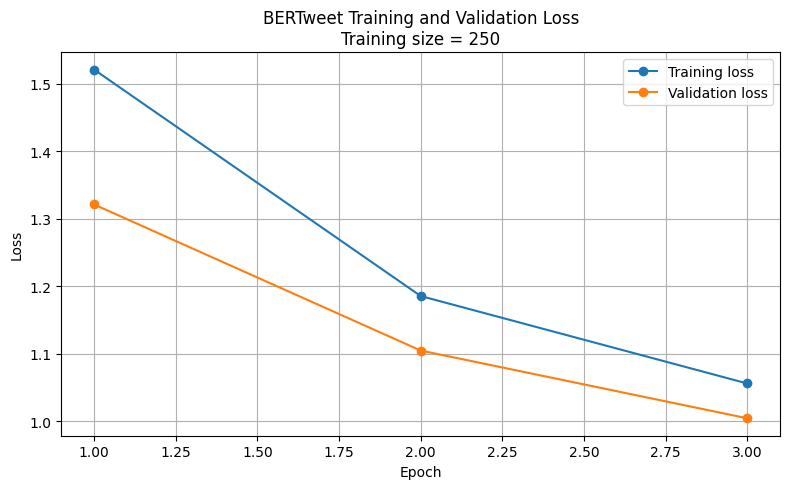

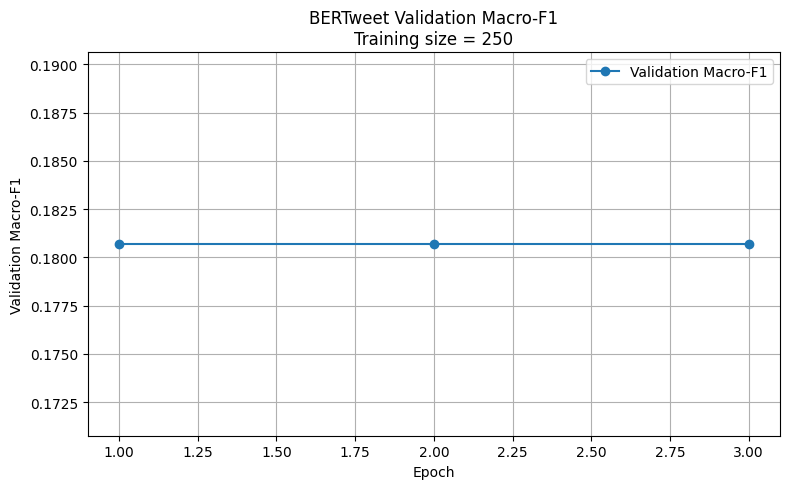

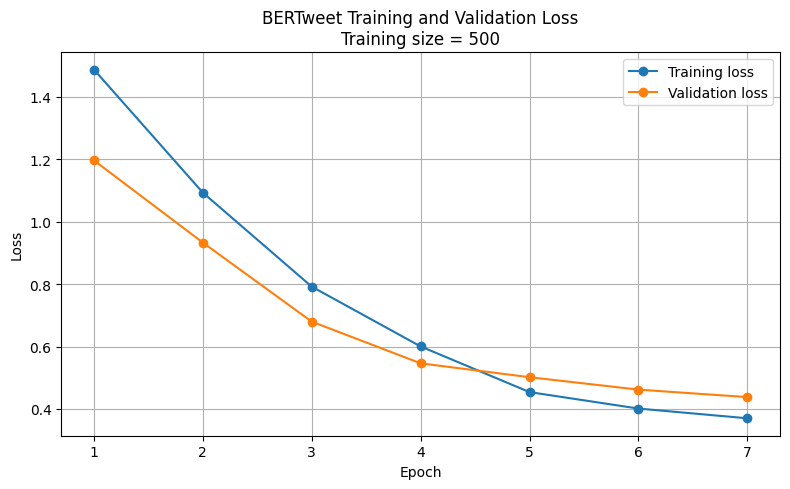

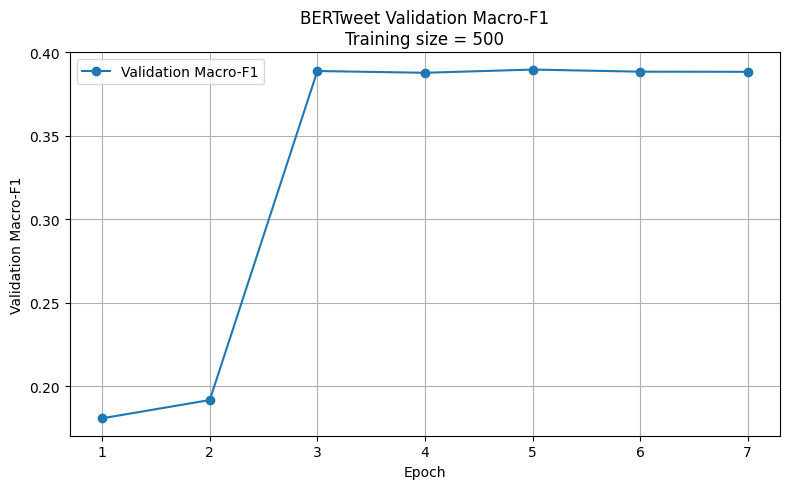

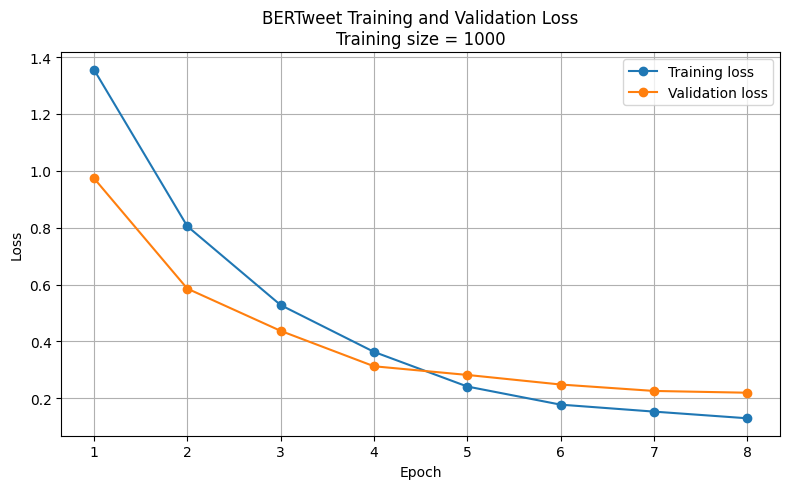

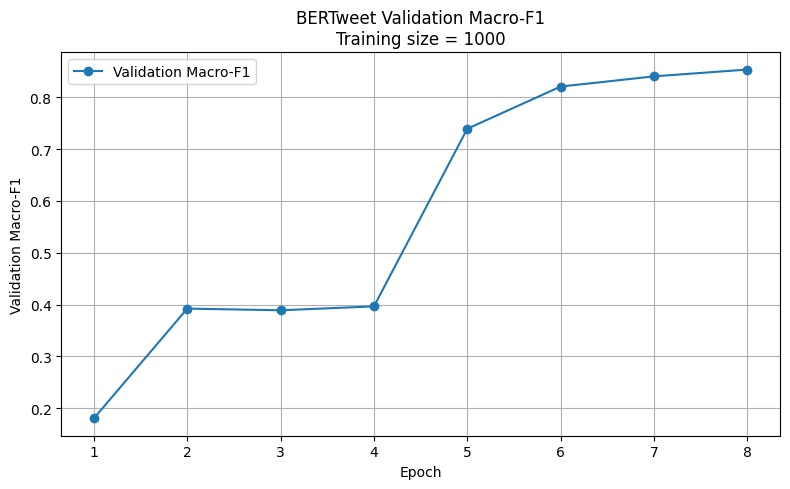

In [ ]:
# Create a directory for low-resource learning curves

LOW_RESOURCE_FIG_DIR = BASE / "figures" / "low_resource"
LOW_RESOURCE_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


for size, history_small in low_resource_histories.items():

    epochs = range(
        1,
        len(history_small["train_loss"]) + 1
    )

    # -----------------------------------------
    # Training and validation loss
    # -----------------------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_small["train_loss"],
        marker="o",
        label="Training loss"
    )

    plt.plot(
        epochs,
        history_small["val_loss"],
        marker="o",
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"BERTweet Training and Validation Loss\n"
        f"Training size = {size}"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        LOW_RESOURCE_FIG_DIR /
        f"m5_bertweet_loss_{size}.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


    # -----------------------------------------
    # Validation Macro-F1
    # -----------------------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_small["val_macro_f1"],
        marker="o",
        label="Validation Macro-F1"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Macro-F1")

    plt.title(
        f"BERTweet Validation Macro-F1\n"
        f"Training size = {size}"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        LOW_RESOURCE_FIG_DIR /
        f"m5_bertweet_macro_f1_{size}.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

##  Interpreting Low-Resource Learning Curves

The learning curves are examined to determine whether the low-resource models were sufficiently trained. In particular, validation macro-F1 is monitored because it is the primary metric for this imbalanced classification task.

If validation macro-F1 continues to increase at the final epoch, this indicates that the model may still benefit from additional training. If validation macro-F1 stops improving and early stopping is triggered, the selected checkpoint provides evidence that further training was not beneficial under the current configuration.

The loss curves are also examined for signs of overfitting. A substantial increase in the gap between training and validation loss, accompanied by declining validation macro-F1, would suggest that additional training may be harming generalisation.

Therefore, the number of epochs is interpreted from the validation learning curves rather than being treated as an arbitrary fixed value.

In [ ]:
# Summarise low-resource training behaviour

learning_curve_summary = []

for size, history_small in low_resource_histories.items():

    val_f1_values = history_small["val_macro_f1"]

    best_epoch = (
        np.argmax(val_f1_values) + 1
    )

    best_val_f1 = max(val_f1_values)

    epochs_trained = len(val_f1_values)

    final_val_f1 = val_f1_values[-1]

    learning_curve_summary.append({
        "training_size": size,
        "epochs_trained": epochs_trained,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_f1,
        "final_val_macro_f1": final_val_f1
    })

learning_curve_summary_df = pd.DataFrame(
    learning_curve_summary
)

display(learning_curve_summary_df)

,training_size,epochs_trained,best_epoch,best_val_macro_f1,final_val_macro_f1
0,250,3,1,0.180694,0.180694
1,500,7,5,0.389620,0.388280
2,1000,8,8,0.853212,0.853212


In [ ]:
#Save the final Model 5 results in the group's format

precision, recall, f1_values, support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(LABELS))),
        zero_division=0
    )
)

final_row = {
    "model": "M5 BERTweet",
    "split": "test",
    "config": f"full data, lr={BEST_LR}, max_length={MAX_LENGTH}",
    "macro_f1": f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    ),
    "balanced_acc": balanced_accuracy_score(
        y_true,
        y_pred
    ),
    "weighted_f1": f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    ),
    "accuracy": accuracy_score(
        y_true,
        y_pred
    ),
    "f1_sexual": f1_values[0],
    "f1_physical": f1_values[1],
    "f1_emotional": f1_values[2],
    "f1_economic": f1_values[3],
    "f1_harmful trad.": f1_values[4],
    "note": "BERTweet; class-weighted loss; selected on validation macro-F1"
}

m5_results = pd.DataFrame([final_row])

display(
    m5_results
)

,model,split,config,macro_f1,balanced_acc,weighted_f1,accuracy,f1_sexual,f1_physical,f1_emotional,f1_economic,f1_harmful trad.,note
0,M5 BERTweet,test,"full data, lr=1e-05, max_length=80",0.998821,0.999918,0.999664,0.999664,0.999796,0.999438,0.994872,1.0,1.0,BERTweet; class-weighted loss; selected on val...


In [ ]:
# Put the low-resource results into a table

sample_results_df = pd.DataFrame(
    sample_results
)

display(
    sample_results_df.sort_values(
        "train_size"
    )
)

sample_results_df.to_csv(
    BASE / "results" /
    "results_model5_low_resource.csv",
    index=False
)

print(
    "Saved low-resource results."
)

,model,train_size,seed,epochs_trained,best_epoch,best_val_macro_f1,macro_f1,accuracy,balanced_acc,weighted_f1,f1_sexual,f1_physical,f1_emotional,f1_economic,f1_harmful_traditional_practice
0,M5 BERTweet,250,42,3,1,0.180694,0.180668,0.823717,0.200000,0.744096,0.903339,0.000000,0.000000,0.000000,0.000000
1,M5 BERTweet,500,42,7,5,0.389620,0.390193,0.969050,0.396401,0.955931,0.985180,0.965784,0.000000,0.000000,0.000000
2,M5 BERTweet,1000,42,8,8,0.853212,0.815434,0.987048,0.775825,0.985522,0.992686,0.989807,0.782123,0.969697,0.342857


Saved low-resource results.


In [ ]:
m5_results.to_csv(
    BASE / "results" /
    "results_model5_bertweet.csv",
    index=False
)